In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
import os
print(os.getcwd())

C:\Users\anand


In [6]:
df = pd.read_csv("student_data.csv")

In [7]:
df.head()

,gender,parental_education,study_hours,attendance,sleep_hours,previous_score,math_score
0,Male,Bachelor,2,78,6,60,65
1,Female,Master,5,92,8,88,91
2,Male,High School,1,65,5,45,50
3,Female,Bachelor,4,89,7,80,84
4,Male,Master,6,95,8,90,94


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   gender              30 non-null     object
 1   parental_education  30 non-null     object
 2   study_hours         30 non-null     int64 
 3   attendance          30 non-null     int64 
 4   sleep_hours         30 non-null     int64 
 5   previous_score      30 non-null     int64 
 6   math_score          30 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 1.8+ KB


In [9]:
df.describe()

,study_hours,attendance,sleep_hours,previous_score,math_score
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,3.466667,81.033333,6.800000,69.966667,73.800000
std,1.756433,11.807313,1.095445,17.337389,17.277452
min,1.000000,60.000000,5.000000,40.000000,45.000000
25%,2.000000,70.250000,6.000000,55.500000,58.500000
50%,3.500000,83.500000,7.000000,73.000000,76.500000
75%,5.000000,90.750000,8.000000,85.750000,89.750000
max,6.000000,97.000000,8.000000,93.000000,97.000000


In [10]:
df.isnull().sum()

gender                0
parental_education    0
study_hours           0
attendance            0
sleep_hours           0
previous_score        0
math_score            0
dtype: int64

In [11]:
df.columns

Index(['gender', 'parental_education', 'study_hours', 'attendance',
       'sleep_hours', 'previous_score', 'math_score'],
      dtype='object')

In [12]:
df.rename(columns={
    'math score': 'math_score',
    'reading score': 'reading_score',
    'writing score': 'writing_score'
}, inplace=True)

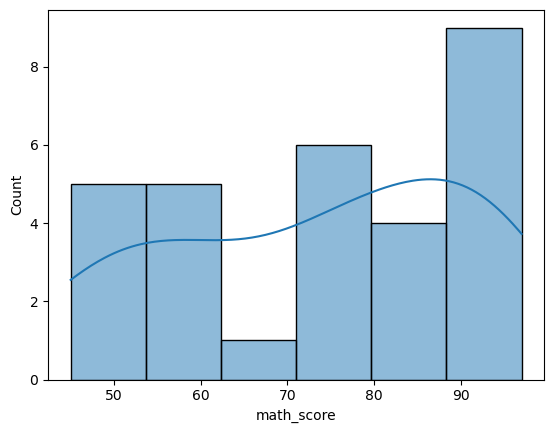

In [13]:
sns.histplot(df['math_score'], kde=True)
plt.show()

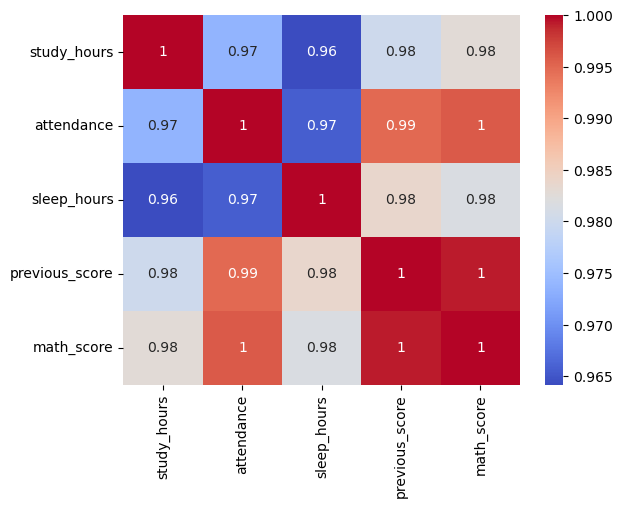

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

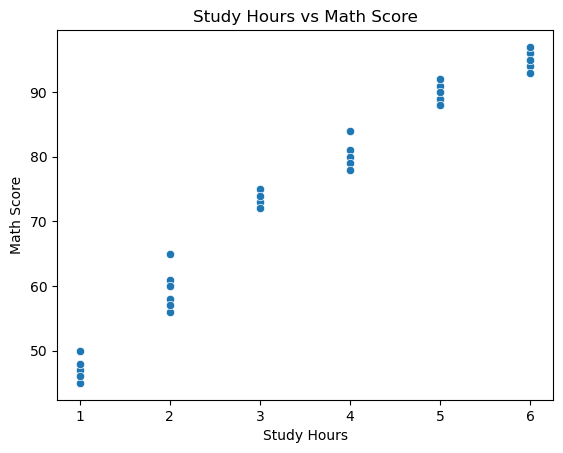

In [16]:
sns.scatterplot(x='study_hours', y='math_score', data=df)

plt.xlabel("Study Hours")
plt.ylabel("Math Score")
plt.title("Study Hours vs Math Score")

plt.show()

In [18]:
X = df[['study_hours', 'attendance', 'sleep_hours', 'previous_score']]

y = df['math_score']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
predictions = model.predict(X_test)

print(predictions)

[78.51601045 80.55752693 60.14247901 55.9950198  43.9351862  82.12087741]


In [22]:
predictions = model.predict(X_test)

In [23]:
print(predictions[:5])

[78.51601045 80.55752693 60.14247901 55.9950198  43.9351862 ]


In [24]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

print(comparison.head())

    Actual  Predicted
27      78  78.516010
15      80  80.557527
23      60  60.142479
17      56  55.995020
8       45  43.935186


In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

In [26]:
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 0.5677813001302425


In [27]:
r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.9973777448203036


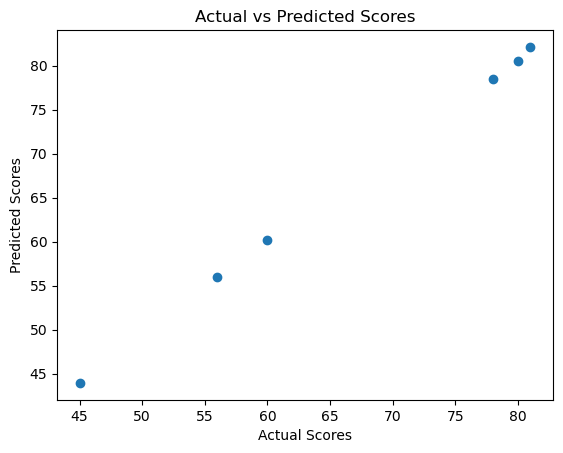

In [28]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")

plt.show()

In [30]:
sample = [[4, 85, 7, 78]]

In [32]:
sample = pd.DataFrame({
    'study_hours': [4],
    'attendance': [85],
    'sleep_hours': [7],
    'previous_score': [78]
})

In [33]:
prediction = model.predict(sample)

print("Predicted Math Score:", prediction[0])

Predicted Math Score: 80.68637942946164


In [34]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [35]:
import joblib

joblib.dump(model, "student_model.pkl")

['student_model.pkl']

In [36]:
loaded_model = joblib.load("student_model.pkl")